In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Задача исследовать файл daily_rent_detail.csv

- читаю файл bike_share/daily_rent_detail.csv

In [2]:
daily_rent_detail = pd.read_csv('../../bike_share/daily_rent_detail.csv')
daily_rent_detail

C:\Users\lenov\AppData\Local\Temp\ipykernel_26912\2254643125.py:1: DtypeWarning: Columns (0: start_station_id, 1: end_station_id) have mixed types. Specify dtype option on import or set low_memory=False.
  daily_rent_detail = pd.read_csv('../../bike_share/daily_rent_detail.csv')


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,946D42AD89539210,docked_bike,2020-05-30 17:25:29,2020-05-31 18:25:22,Anacostia Library,31804,11th & H St NE,31614.0,38.865784,-76.978400,38.899983,-76.991383,casual
1,CC46FAAB662B8613,docked_bike,2020-05-09 14:42:04,2020-05-09 15:06:33,10th & E St NW,31256,21st St & Constitution Ave NW,31261.0,38.895914,-77.026064,38.892459,-77.046567,member
2,72F00B2FB833D6ED,docked_bike,2020-05-24 17:27:19,2020-05-24 17:43:51,Connecticut Ave & Newark St NW / Cleveland Park,31305,12th & U St NW,31268.0,38.934267,-77.057979,38.916787,-77.028139,member
3,4DFBE6AED989DF35,docked_bike,2020-05-27 15:29:52,2020-05-27 15:47:13,Connecticut Ave & Newark St NW / Cleveland Park,31305,14th & Belmont St NW,31119.0,38.934267,-77.057979,38.921074,-77.031887,casual
4,1AAFE6B4331AB9DF,docked_bike,2020-05-31 14:06:03,2020-05-31 14:30:30,Georgia Ave & Morton St NW,31419,17th & K St NW,31213.0,38.932128,-77.023500,38.902760,-77.038630,casual
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16086667,117C27DBDD138B72,electric_bike,2024-08-01 08:10:22.293,2024-08-01 08:10:37.641,NaN,NaN,NaN,NaN,38.890000,-77.000000,38.890000,-77.000000,member
16086668,4774F4D630258482,electric_bike,2024-08-08 10:05:21.938,2024-08-08 10:21:46.654,NaN,NaN,NaN,NaN,38.900000,-77.000000,38.870000,-76.950000,member
16086669,D75836E25E77B5EC,electric_bike,2024-08-03 16:29:32.252,2024-08-03 16:35:43.179,NaN,NaN,NaN,NaN,38.920000,-76.990000,38.920000,-77.000000,member
16086670,3B888603D18116DC,electric_bike,2024-08-03 02:49:45.661,2024-08-03 02:59:56.877,NaN,NaN,NaN,NaN,38.920000,-77.020000,38.920000,-77.030000,member


### Общая информация о данных

- сначала выведу info о dataframe

In [3]:
daily_rent_detail.info()

<class 'pandas.DataFrame'>
RangeIndex: 16086672 entries, 0 to 16086671
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ride_id             str    
 1   rideable_type       str    
 2   started_at          str    
 3   ended_at            str    
 4   start_station_name  str    
 5   start_station_id    object 
 6   end_station_name    str    
 7   end_station_id      object 
 8   start_lat           float64
 9   start_lng           float64
 10  end_lat             float64
 11  end_lng             float64
 12  member_casual       str    
dtypes: float64(4), object(2), str(7)
memory usage: 1.6+ GB


- вывел описание

In [4]:
daily_rent_detail.describe()

,start_lat,start_lng,end_lat,end_lng
count,1.608666e+07,1.608666e+07,1.606074e+07,1.606074e+07
mean,3.890389e+01,-7.703200e+01,3.890290e+01,-7.703162e+01
std,2.758673e-02,3.436006e-02,4.704474e-02,8.250517e-02
min,3.873000e+01,-7.740000e+01,0.000000e+00,-7.810000e+01
25%,3.889054e+01,-7.704463e+01,3.889050e+01,-7.704468e+01
50%,3.890304e+01,-7.703150e+01,3.890257e+01,-7.703000e+01
75%,3.891554e+01,-7.701350e+01,3.891305e+01,-7.701237e+01
max,3.914000e+01,-7.678414e+01,4.307000e+01,0.000000e+00


- решаю посмотреть сколько строк end_lng равно 0

In [5]:
len(daily_rent_detail[daily_rent_detail['end_lng'] == 0.0])

15

### Отсутствующие значения

- посмотрел сколько отсутствующих значаний (отсутствующие значение есть хотя бы в одной строке)

In [6]:
missing_data = daily_rent_detail[daily_rent_detail.isnull().any(axis=1)]

- вывожу результат отсутствующих значений

In [7]:
missing_data

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
115247,1ED943ECA468B443,docked_bike,2020-05-12 11:48:11,2020-05-12 12:53:26,Maryland Ave & 17th St NE,31656,NaN,NaN,38.901935,-76.978627,NaN,NaN,casual
115249,87980D1F271A7BC3,docked_bike,2020-05-05 20:06:04,2020-05-06 13:39:34,M St & Pennsylvania Ave NW,31246,NaN,NaN,38.905126,-77.056887,NaN,NaN,member
115251,A763EAE06D1C47E7,docked_bike,2020-05-02 13:12:14,2020-05-02 17:51:27,4th & M St SW,31108,NaN,NaN,38.876700,-77.017800,NaN,NaN,casual
115254,5D36D7EDEA24EC45,docked_bike,2020-05-16 12:33:15,2020-05-16 13:01:26,M St & Pennsylvania Ave NW,31246,NaN,NaN,38.905126,-77.056887,NaN,NaN,member
115258,5ECE4E0CB655AA09,docked_bike,2020-05-08 15:23:15,2020-05-08 18:55:52,M St & Pennsylvania Ave NW,31246,NaN,NaN,38.905126,-77.056887,NaN,NaN,casual
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16086667,117C27DBDD138B72,electric_bike,2024-08-01 08:10:22.293,2024-08-01 08:10:37.641,NaN,NaN,NaN,NaN,38.890000,-77.000000,38.89,-77.00,member
16086668,4774F4D630258482,electric_bike,2024-08-08 10:05:21.938,2024-08-08 10:21:46.654,NaN,NaN,NaN,NaN,38.900000,-77.000000,38.87,-76.95,member
16086669,D75836E25E77B5EC,electric_bike,2024-08-03 16:29:32.252,2024-08-03 16:35:43.179,NaN,NaN,NaN,NaN,38.920000,-76.990000,38.92,-77.00,member
16086670,3B888603D18116DC,electric_bike,2024-08-03 02:49:45.661,2024-08-03 02:59:56.877,NaN,NaN,NaN,NaN,38.920000,-77.020000,38.92,-77.03,member


- нужно посмотреть в чем причина

- меняю тип данных для столбца started_at

In [8]:
daily_rent_detail['started_at'] = pd.to_datetime(daily_rent_detail['started_at'], format='mixed')

- добавляю столбец year

In [9]:
daily_rent_detail['year'] = daily_rent_detail['started_at'].dt.year

- добавляю столбец month

In [10]:
daily_rent_detail['month'] = daily_rent_detail['started_at'].dt.month

- посмотрю какие типы велосипедов были в этих данных

In [12]:
missing_data['rideable_type'].value_counts()

rideable_type
electric_bike    2123791
classic_bike       23638
docked_bike        11026
Name: count, dtype: int64

- в исходном dataframe 

In [13]:
daily_rent_detail['rideable_type'].value_counts()

rideable_type
classic_bike     9614139
electric_bike    4616748
docked_bike      1855785
Name: count, dtype: int64

- значит смотрю только на electric_bike

- посмотрю занимаемую долю отсутствующих значений, буду брать столбец год и месяц

In [15]:
missing_by_year_month = daily_rent_detail[daily_rent_detail['rideable_type']=='electric_bike'].groupby(['year', 'month'])['start_station_id'].apply(lambda x: x.isna().mean()).to_frame()
missing_by_year_month

start_station_id
year month                  
2020 6              0.825397
     7              0.248321
     8              0.320090
     9              0.363114
     10             0.371101
     11             0.376883
     12             0.391306
2021 1              0.377465
     2              0.368978
     3              0.388075
     4              0.400720
     5              0.402819
     6              0.420167
     7              0.425540
     8              0.423451
     9              0.404937
     10             0.319654
     11             0.270942
     12             0.258338
2022 1              0.235938
     2              0.210782
     3              0.240082
     4              0.240137
     5              0.259895
     6              0.265871
     7              0.280011
     8              0.282874
     9              0.298160
     10             0.287019
     11             0.304089
     12             0.316381
2023 1              0.335051
     2              0.300138
     3              0.293738
     4              0.249609
     5              0.261571
     6              0.296359
     7              0.296380
     8              0.291792
     9              0.305928
     10             0.288488
     11             0.293645
     12             0.308742
2024 1              0.304670
     2              0.296822
     3              0.298095
     4              0.308961
     5              0.329134
     6              0.340182
     7              0.339030
     8              0.328282

- также хочу посмотреть количество станций, которые работали

In [24]:
quantity_stations = daily_rent_detail.groupby(['year', 'month'])['start_station_id'].nunique().to_frame()
quantity_stations

start_station_id
year month                  
2020 5                   598
     6                   599
     7                   599
     8                   604
     9                   608
     10                  608
     11                  611
     12                  610
2021 1                   621
     2                   922
     3                   624
     4                   628
     5                   628
     6                   631
     7                   647
     8                   653
     9                   654
     10                  658
     11                  661
     12                  668
2022 1                   648
     2                   668
     3                   678
     4                   682
     5                   684
     6                   683
     7                   685
     8                   692
     9                   699
     10                  699
     11                  698
     12                  699
2023 1                   712
     2                   716
     3                   720
     4                   727
     5                   727
     6                   736
     7                   738
     8                   738
     9                   738
     10                  745
     11                  755
     12                  761
2024 1                   758
     2                   765
     3                   772
     4                   781
     5                   783
     6                   788
     7                   782
     8                   776

- добавляю столбец quantity_station к dataframe "missing_by_year_month"

In [17]:
missing_by_year_month['quantity_station'] = quantity_stations['start_station_id']

- сбрасываю индексы для того что бы вывести данные на график

In [18]:
missing_by_month = missing_by_year_month.reset_index()

- перобразую дату для графика

In [19]:
missing_by_month['date'] = missing_by_month['year'].astype('str') + '-' + missing_by_month['month'].astype('str')

- вывожу результат

In [20]:
missing_by_month

,year,month,start_station_id,quantity_station,date
0,2020,6,0.825397,599,2020-6
1,2020,7,0.248321,599,2020-7
2,2020,8,0.320090,604,2020-8
3,2020,9,0.363114,608,2020-9
4,2020,10,0.371101,608,2020-10
5,2020,11,0.376883,611,2020-11
6,2020,12,0.391306,610,2020-12
7,2021,1,0.377465,621,2021-1
8,2021,2,0.368978,922,2021-2
9,2021,3,0.388075,624,2021-3


- вывожу график

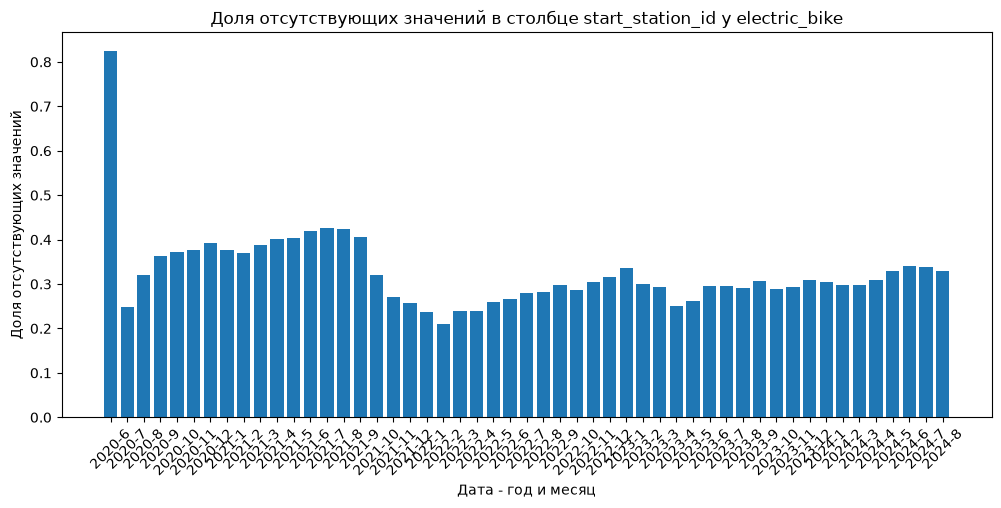

In [21]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(
    missing_by_month['date'],
    missing_by_month['start_station_id'],
)

ax.set_title('Доля отсутствующих значений в столбце start_station_id у electric_bike')
ax.set_ylabel('Доля отсутствующих значений')
ax.set_xlabel('Дата - год и месяц')

ax.tick_params(axis='x', rotation=45)

plt.show()

- Изначально была мысль что инфраструктура не поспевает за electric_bike
- Это не подтвердилось, потому что из года в год доля отсутствующих значений становилось бы меньше
- В целом доля состовляет от 30 до 40 процентов
- Информация из интернета:
    - Электровелосипеды Capital Bikeshare можно оставить на любой станции Capital Bikeshare или пристегнуть
    - к любой общественной велопарковке в зоне обслуживания в Вашингтоне, Вирджинии и Мэриленде.
    - Парковка на станциях бесплатна; за пристегивание к общественной велопарковке взимается плата в размере 1 доллара.

- вывожу график "Количество станций за весь период"

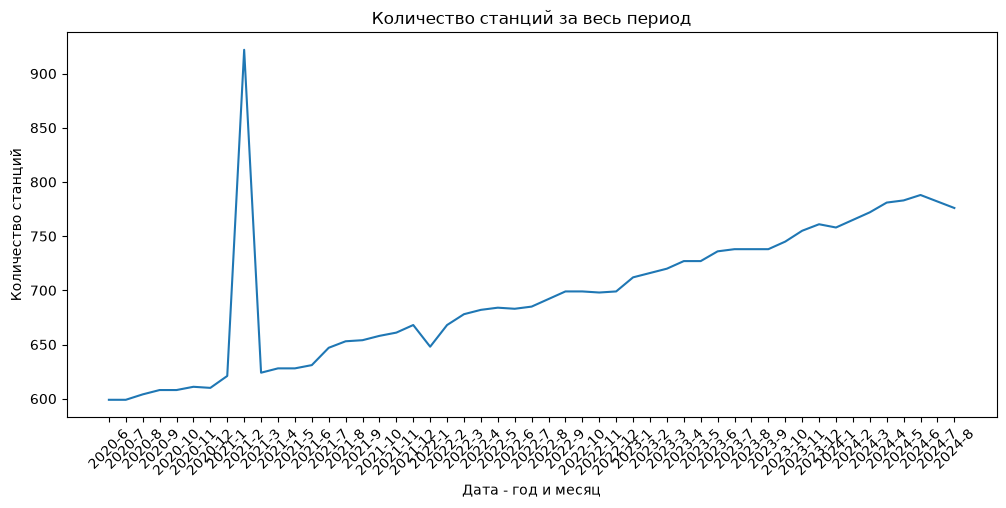

In [22]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    missing_by_month['date'],
    missing_by_month['quantity_station'],
)
ax.set_title('Количество станций за весь период')
ax.set_ylabel('Количество станций')
ax.set_xlabel('Дата - год и месяц')

ax.tick_params(axis='x', rotation=45)

plt.show()

- Это еще ковидные времена - может быть рост был связан с какими то послаблениями по карантину

- количество отсутствующих значений по каждому столбцу

In [8]:
daily_rent_detail.isna().sum()

ride_id                     0
rideable_type               0
started_at                  0
ended_at                    0
start_station_name    1450150
start_station_id      1450150
end_station_name      1558268
end_station_id        1558917
start_lat                  10
start_lng                  10
end_lat                 25929
end_lng                 25929
member_casual               0
dtype: int64

### Дубликаты

- сначала посмотрю какие строки повтояются

In [9]:
daily_rent_detail[daily_rent_detail.duplicated()]

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual


### Описательная статистика

In [10]:
round(daily_rent_detail['start_lat'].mean(), 6), round(daily_rent_detail['start_lng'].mean(), 6)

(np.float64(38.903892), np.float64(-77.031997))

In [11]:
round(daily_rent_detail['end_lat'].mean(), 6), round(daily_rent_detail['end_lng'].mean(), 6)

(np.float64(38.902901), np.float64(-77.031619))

In [12]:
daily_rent_detail.describe()

,start_lat,start_lng,end_lat,end_lng
count,1.608666e+07,1.608666e+07,1.606074e+07,1.606074e+07
mean,3.890389e+01,-7.703200e+01,3.890290e+01,-7.703162e+01
std,2.758673e-02,3.436006e-02,4.704474e-02,8.250517e-02
min,3.873000e+01,-7.740000e+01,0.000000e+00,-7.810000e+01
25%,3.889054e+01,-7.704463e+01,3.889050e+01,-7.704468e+01
50%,3.890304e+01,-7.703150e+01,3.890257e+01,-7.703000e+01
75%,3.891554e+01,-7.701350e+01,3.891305e+01,-7.701237e+01
max,3.914000e+01,-7.678414e+01,4.307000e+01,0.000000e+00


### Распределение признаков

- для начала сделам некоторые преодразования

- заменяю в столбце start_station_id и end_station_id Nan на 0

In [13]:
daily_rent_detail['start_station_id'] = daily_rent_detail['start_station_id'].replace(np.nan, 0)

In [14]:
daily_rent_detail['end_station_id'] = daily_rent_detail['end_station_id'].replace(np.nan, 0)

- убираю из dataframe станцию 'MTL-ECO5-03' (в dataframe там весго 2 строки)

In [15]:
daily_rent_detail = daily_rent_detail[daily_rent_detail['start_station_id'] != 'MTL-ECO5-03']

- меняю типы данных

In [ ]:
daily_rent_detail = daily_rent_detail.astype(
    {   
        'start_station_id': 'float32',
        'end_station_id': 'float32',
        'started_at': 'datetime64[ns]',
        'ended_at': 'datetime64[ns]'
    }
)

In [17]:
daily_rent_detail = daily_rent_detail.astype(
    {   
        'start_station_id': 'int32',
        'end_station_id': 'int32'
    }
)

- добавляю новый столбец duration_in_minutes и перевожу сразу в минуты

In [18]:
daily_rent_detail['duration_in_minutes'] = daily_rent_detail['ended_at'] - daily_rent_detail['started_at']

In [19]:
daily_rent_detail['duration_in_minutes'] = daily_rent_detail['duration_in_minutes'].dt.total_seconds().div(60)

- сморю сколько данных в столбце duration_in_minutes меньше 0

In [20]:
daily_rent_detail[daily_rent_detail['duration_in_minutes'] < 0]

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,duration_in_minutes
277,7741E79C751B7926,docked_bike,2020-05-24 18:58:35,2020-05-24 18:58:19,14th & Upshur St NW,31406,Eckington Pl & Q St NE,31505,38.942475,-77.032678,38.910972,-77.00495,member,-0.266667
402,33DC5D203FA43705,docked_bike,2020-05-30 13:17:14,2020-05-30 13:17:01,12th & U St NW,31268,Eckington Pl & Q St NE,31505,38.916787,-77.028139,38.910972,-77.00495,member,-0.216667
469,6E38B3180C7CE430,docked_bike,2020-05-25 14:59:49,2020-05-25 14:59:36,14th & R St NW,31202,Eckington Pl & Q St NE,31505,38.913046,-77.032008,38.910972,-77.00495,member,-0.216667
516,6B0B820C0A891D00,docked_bike,2020-05-19 14:49:41,2020-05-19 14:49:28,3rd & H St NE,31616,Eckington Pl & Q St NE,31505,38.900412,-77.001949,38.910972,-77.00495,member,-0.216667
519,6A3FB558399C737D,docked_bike,2020-05-27 20:06:18,2020-05-27 20:06:06,1st & M St NE,31603,Eckington Pl & Q St NE,31505,38.905700,-77.005600,38.910972,-77.00495,member,-0.200000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14289369,F289CCBB807221D9,electric_bike,2024-05-19 17:31:40,2024-05-19 17:31:39,NaN,0,NaN,0,38.950000,-77.020000,38.950000,-77.02000,casual,-0.016667
14291388,D7781AC58C80A5A3,electric_bike,2024-05-13 17:42:43,2024-05-13 17:41:51,NaN,0,NaN,0,38.940000,-77.060000,38.940000,-77.06000,member,-0.866667
14294094,585B15F2F75AC4B2,electric_bike,2024-05-19 16:54:05,2024-05-19 16:54:04,NaN,0,NaN,0,38.870000,-77.000000,38.870000,-77.00000,casual,-0.016667
14295780,4219C6360270F68C,electric_bike,2024-05-14 11:17:09,2024-05-14 11:17:08,NaN,0,NaN,0,38.960000,-76.980000,38.960000,-76.98000,casual,-0.016667


- подготавливаю данные для графика фильтруя по столбцу duration_in_minutes от 0 да 60 минут включительно

In [21]:
df_for_plot = daily_rent_detail[(daily_rent_detail['duration_in_minutes'] >= 0) & (daily_rent_detail['duration_in_minutes'] <= 60)]

- строю гистограмму "распределение продолжительности поездок"

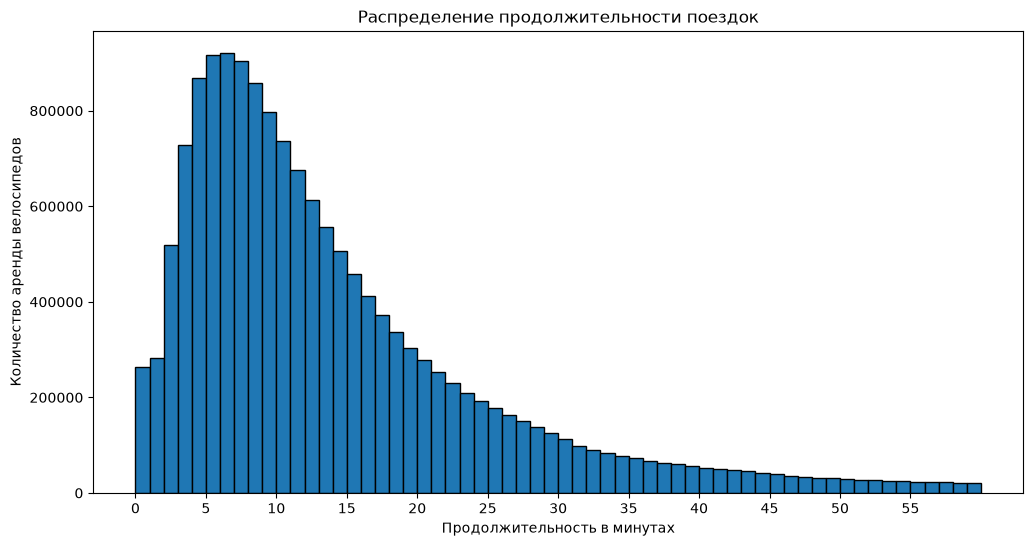

In [22]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(
    df_for_plot['duration_in_minutes'],
    bins=60,
    edgecolor='black'
)

plt.xlabel('Продолжительность в минутах')
plt.ylabel('Количество аренды велосипедов')
plt.title('Распределение продолжительности поездок')
plt.xticks(np.arange(0, 60, 5))

plt.show()

- добавляю столбец hour, что бы затем посторить график

In [23]:
daily_rent_detail['hour'] = daily_rent_detail['started_at'].dt.hour

- подготавливаю данные для график (bar)

In [24]:
hour_counts = daily_rent_detail['hour'].value_counts().sort_index()
hour_counts

hour
0      177982
1      108248
2       66538
3       36504
4       33343
5       90703
6      258231
7      562829
8      937875
9      766566
10     721831
11     838148
12     962283
13     984934
14    1014106
15    1127838
16    1259960
17    1576697
18    1405086
19    1063912
20     761599
21     579275
22     447328
23     304854
Name: count, dtype: int64

- строю график (bar) "количество аренд по часам суток"

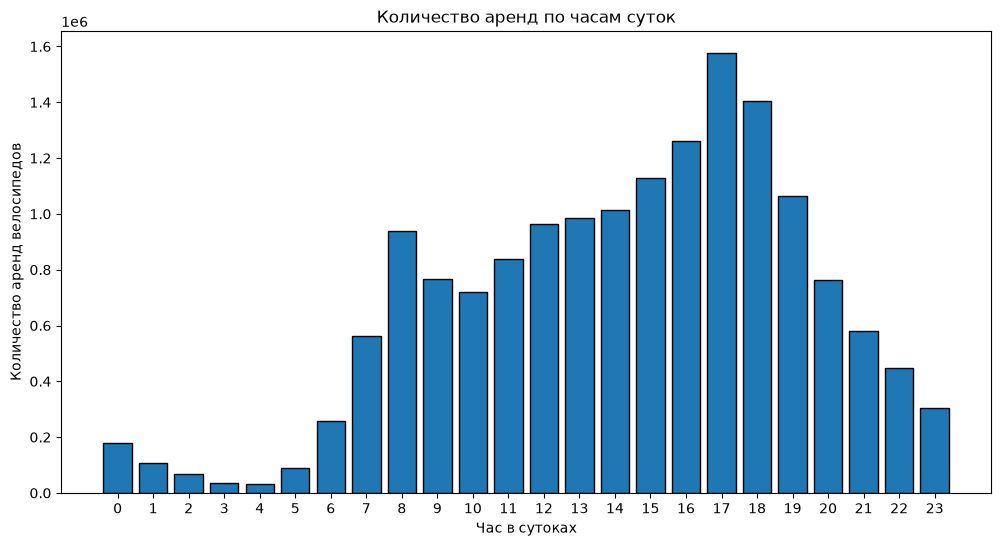

In [25]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    hour_counts.index,
    hour_counts.values,
    edgecolor='black'
)

plt.xlabel('Час в сутоках')
plt.ylabel('Количество аренд велосипедов')
plt.title('Количество аренд по часам суток')
plt.xticks(np.arange(0, 24, 1))

plt.show()

In [43]:
rideable_type = daily_rent_detail['rideable_type'].value_counts()
rideable_type

rideable_type
classic_bike     9614139
electric_bike    4616748
docked_bike      1855783
Name: count, dtype: int64

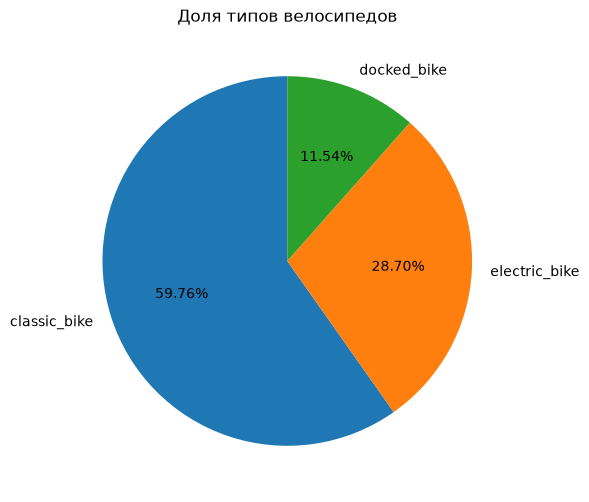

In [50]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.pie(
    rideable_type.values,
    labels=rideable_type.index,
    autopct='%1.2f%%',
    startangle=90
)

plt.title('Доля типов велосипедов')
plt.show()

### Выбросы

- построю boxplot для столбца duration_in_minutes (зная что там уже есть отрицательные значения я их уберу)
- также уберу значения, которые превышают поездку более 60 минут

In [26]:
df_for_boxplot = daily_rent_detail[(daily_rent_detail['duration_in_minutes'] >= 0) & (daily_rent_detail['duration_in_minutes'] <= 60)]

<Axes: >

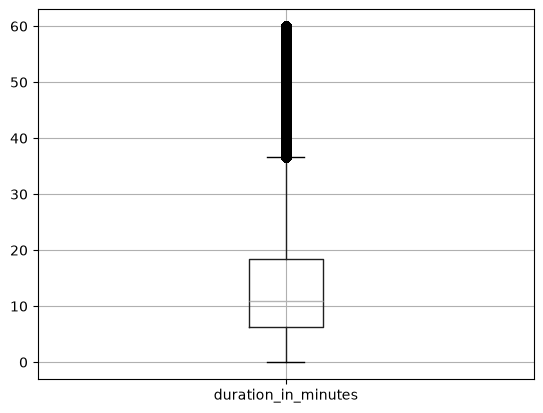

In [27]:
df_for_boxplot.boxplot(column='duration_in_minutes')

- расперделение не симмтричное (имеет правостороннюю асимметрию)
- медиана состовляет примерно 10-11 минут (межквартильный размах)
- 50 % процентов поездок находится в диапазоне от 6 до 18 минут
- основная масса поездок лежит в диапазоне от 0 до 36 минут
- выбросы начинаются от 36 в плоть до 60 минут

<Axes: >

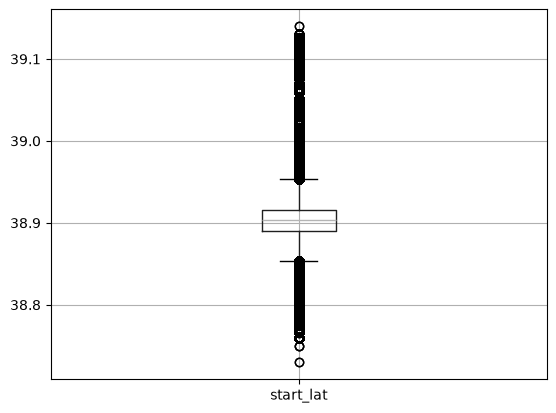

In [32]:
daily_rent_detail.boxplot(column='start_lat')

- расперделение симметричное
- медиана состовляет примерно 38.91
- в целом меня здесь больше интресует что точки имеют не большой разброс (в приделах города)

<Axes: >

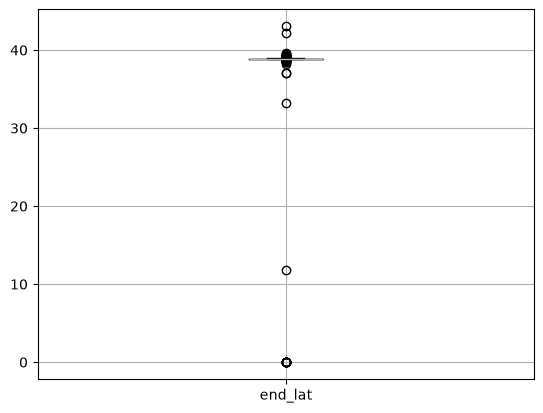

In [33]:
daily_rent_detail.boxplot(column='end_lat')

- здесь наблюдается что есть большие выбросы, но таких данных совсем не много (их можно откинуть)

<Axes: >

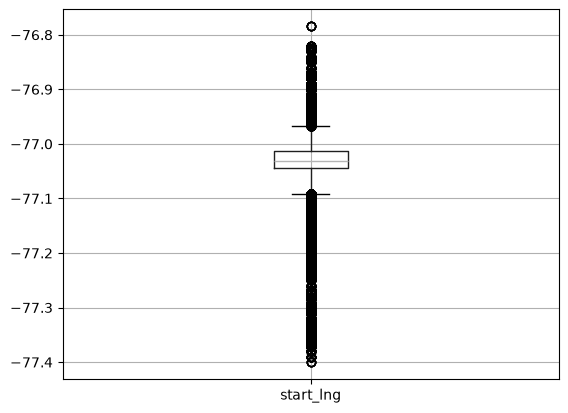

In [34]:
daily_rent_detail.boxplot(column='start_lng')

- расперделение симметричное
- медиана состовляет примерно -77.03
- в целом меня здесь больше интресует что точки имеют не большой разброс (в приделах города)

<Axes: >

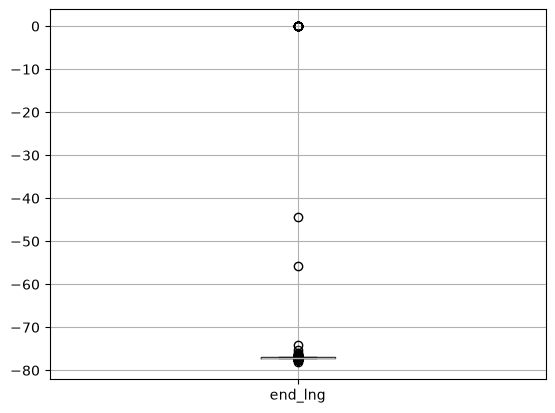

In [35]:
daily_rent_detail.boxplot(column='end_lng')

- такая же ситуация как и в столбце start_lng (дынных, которые имеют большой выброс можно откинуть)

## Выводы

- есть станция 'MTL-ECO5-03', занимает 2 строчки в dataframe
- есть отсутствующие значения в столбцах 
    - start_station_name    1450150
    - start_station_id      1450150
    - end_station_name      1558268
    - end_station_id        1558917
    - start_lat                  10
    - start_lng                  10
    - end_lat                 25929
    - end_lng                 25929

- отсутствующие значения связаны с electric bike 
    - Изначально была мысль что инфраструктура не поспевает за electric_bike
    - Это не подтвердилось, потому что из года в год доля отсутствующих значений становилось бы меньше
    - В целом доля состовляет от 30 до 40 процентов
    - Информация из интернета:
        - Электровелосипеды Capital Bikeshare можно оставить на любой станции Capital Bikeshare или пристегнуть к любой общественной велопарковке в зоне обслуживания в Вашингтоне, Вирджинии и Мэриленде. Парковка на станциях бесплатна; за пристегивание к общественной велопарковке взимается плата в размере 1 доллара.

- есть точки end_lat и end_lng, которые точно не в пределах города 
    - end_lat крайняя точка 37
    - end_lng крайняя точка 76
    - также столбец end_lng имеет 15 строк со значением 0 
- есть отрицательные значения в столбце duration_in_minutes - 8617 строк
- полностью повторяющихся строк не обнаруженно